# Выявление доходных сессий онлайн продаж

In [666]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["figure.dpi"] = 120

In [667]:
df = pd.read_csv("data/online_shoppers_intention.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [668]:
df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## 1. EDA (Exploratory Data Analysis)

In [669]:
# print(df["Revenue"].unique())
df["Revenue"] = df["Revenue"].replace({True: 1, False: 0}).astype(np.int64)
print("Классы доходности: ", df["Revenue"].unique())

print(f"Доля доходных сессий: {df["Revenue"].mean()}")

Классы доходности:  [0 1]
Доля доходных сессий: 0.15474452554744525


В датасете наблюдается сильный дизбаланс классов — на доходные сессии приходится лишь **15.5%**

In [670]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [671]:
print("Представленные месяцы в датасете: ", df["Month"].unique().tolist())

Представленные месяцы в датасете:  ['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']


На какие месяцы приходятся праздничные дни (`SpecialDay`):

Праздничные дни приходятся на февраль и май, подавляющее большинство праздников в мае.

In [672]:
df[df["SpecialDay"] > 0.].groupby("Month").agg(
    {"SpecialDay": "count",
     "Revenue": "mean"}
)

,SpecialDay,Revenue
Month,,
Feb,79,0.025316
May,1172,0.063993


Тем не менее, максимум продаж приходиться на ноябрь, в праздничные дни повышается лишь трафик:

Text(0, 0.5, 'Доля доходных сессий')

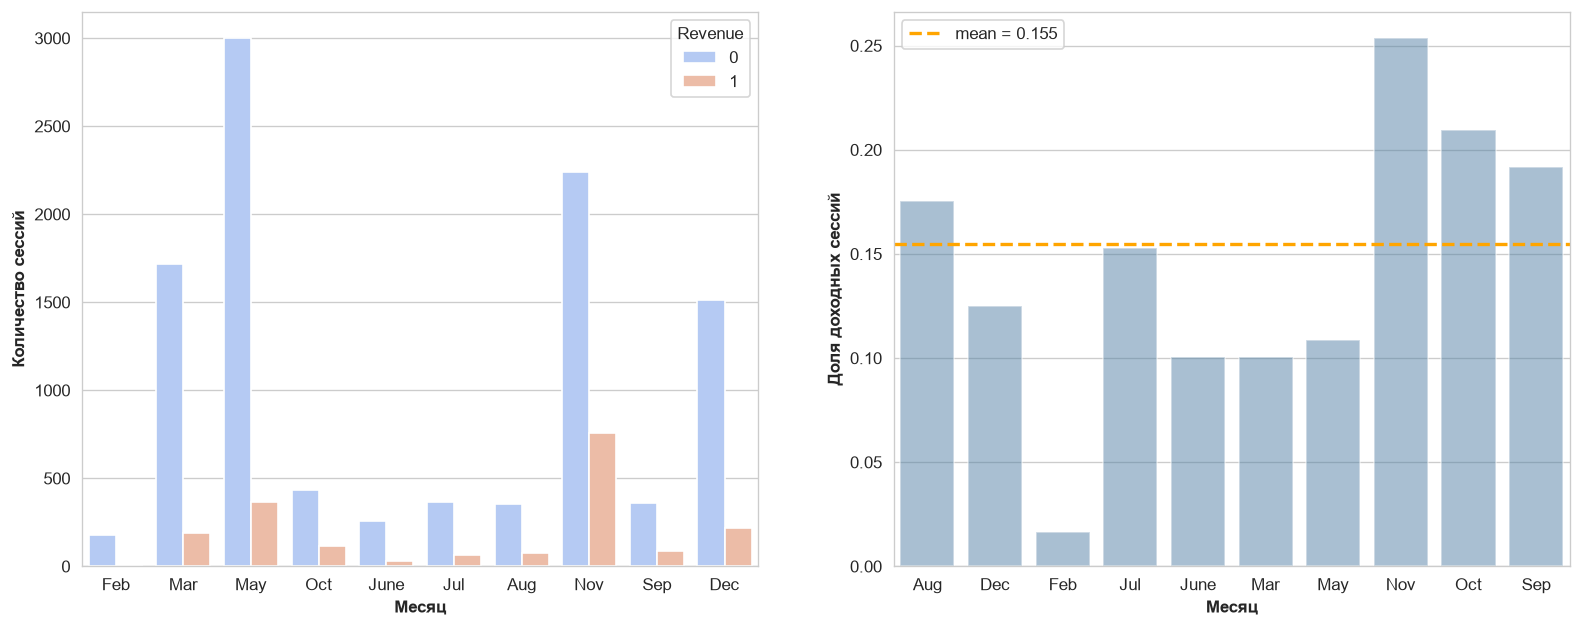

In [673]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))


sns.countplot(x=df["Month"], hue=df['Revenue'], palette='coolwarm', ax=ax[0])
ax[0].set_xlabel("Месяц")
ax[0].set_ylabel("Количество сессий")

data = df.groupby('Month').agg({'Revenue': 'mean'})
sns.barplot(data=data, x="Month", y="Revenue", ax=ax[1], color='steelblue', alpha=0.5)

ax[1].axhline(y=df['Revenue'].mean(), 
              color="orange", linestyle="--", linewidth=2, label=f"mean = {df['Revenue'].mean():0.3f}")

ax[1].legend()

ax[1].set_xlabel("Месяц")
ax[1].set_ylabel("Доля доходных сессий")

# plt.xlabel("Месяц")
# plt.ylabel("Количество сессий")

Т.е. между признаками `SpecialDay` и `Month` ожидается корреляция, при этом все праздничные дни приходятся на два месяца (февраль и май), в течение которых наблюдается повышенный трафик на сайтах и падение доли продаж $\to$ **Гипотеза**: признак `SpecialDay` слабый и только зашумляет целевой признак (`Revenue`)

Продажи по выходным (`Weekend`):

In [674]:
df.groupby("Weekend").agg(
    {"Weekend": "count",
     "Revenue": "mean"}
)

,Weekend,Revenue
Weekend,,
False,9462,0.148911
True,2868,0.173989


Text(0, 0.5, 'Количество сессий')

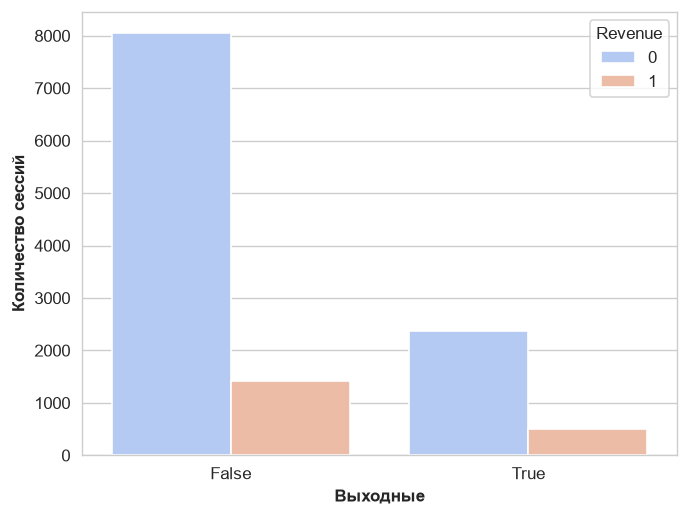

In [675]:
sns.countplot(x=df['Weekend'], hue=df['Revenue'], palette='coolwarm')
plt.xlabel('Выходные')
plt.ylabel('Количество сессий')

Рассмотрим продажи на сайтах по категориям пользователей (`New_Visitor`, `Returning_Visitor`, `Other`):

In [676]:
df.groupby('VisitorType').agg(
    Visitors = ('VisitorType', 'count'),
    Revenue = ('Revenue', 'mean')
)

,Visitors,Revenue
VisitorType,,
New_Visitor,1694,0.249115
Other,85,0.188235
Returning_Visitor,10551,0.139323


Категория `Other` малочисленна по сравнению с категориями `New_Visitor` и `Returning_Visitor` $\to$ пренебрежем этой категорией и выбросим все вхождения с категорией `VisitorType = Other`

In [677]:
df = df[(df['VisitorType'] != 'Other')].reset_index(drop=True)

Проиндексируем категориальные признаки для оценки корреляции признаков и построения логистической регрессии:

In [ ]:
months = df['Month'].unique()
df['Month'] = df['Month'].replace({month: i for month, i in zip(months, range(len(months)))}).astype(np.int64)

visitors = df['VisitorType'].unique()
df['VisitorType'] = df['VisitorType'].replace({visitor: i for visitor, i in zip(visitors, range(len(visitors)))}).astype(np.int64)

# df['VisitorType'].astype(np.int64)
df['Weekend'] = df['Weekend'].astype(np.int64)

Рассмотрим сайты по числовым параметрам:

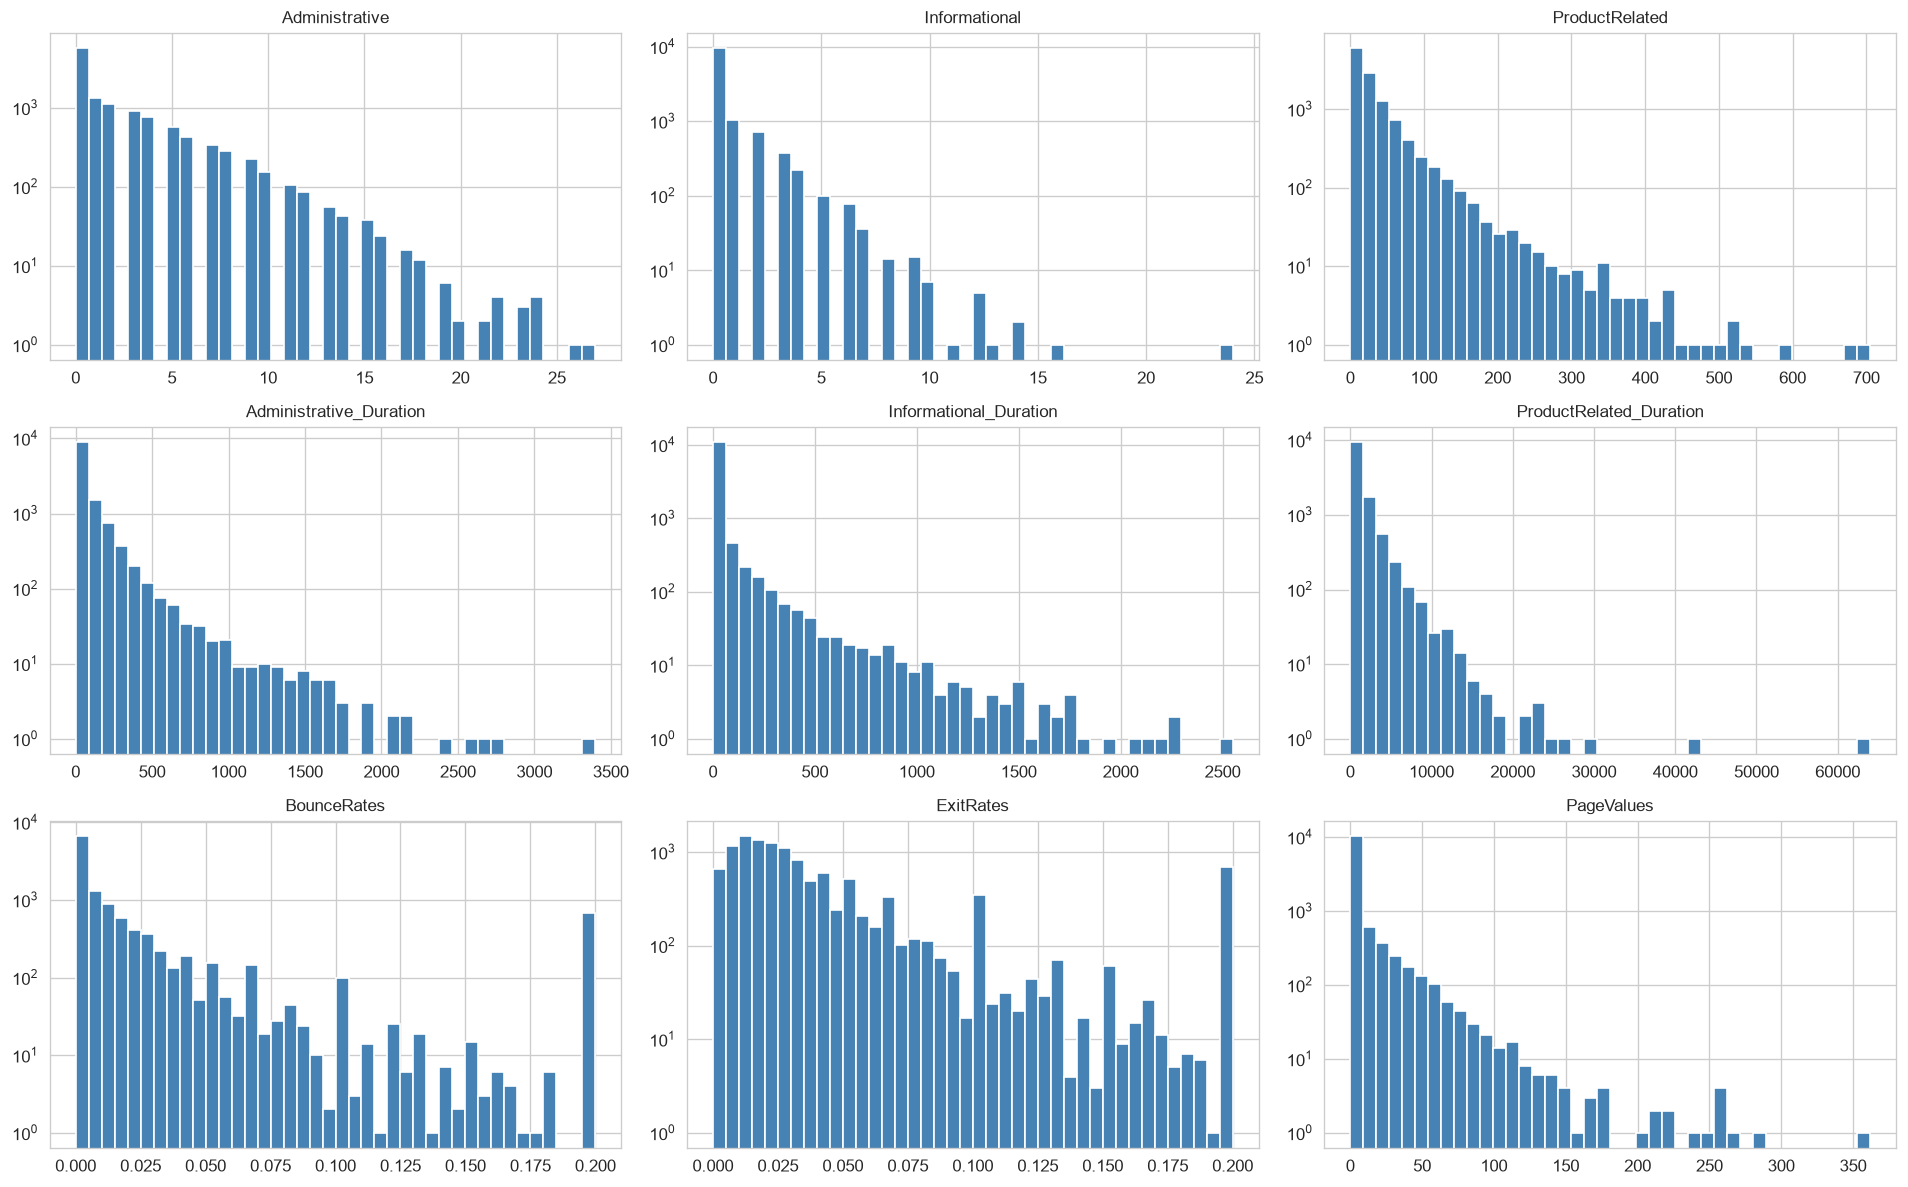

In [679]:
check_columns = ['Administrative', 'Informational', 'ProductRelated', 'Administrative_Duration',
                 'Informational_Duration', 'ProductRelated_Duration',
                 'BounceRates', 'ExitRates', 'PageValues']

fig, ax = plt.subplots(3, 3, figsize=(16,10))
ax = ax.flatten()

for i, col in enumerate(check_columns):
    df[col].hist(bins=40, ax=ax[i], color='steelblue', edgecolor='white')
    ax[i].set_title(col, fontsize=10)
    ax[i].set_yscale('log')

plt.tight_layout()
plt.show()

**ВАЖНОЕ ЗАМЕЧАНИЕ:**

Заметно, что согласно представленным гистограммам, в датасете имеются сайты со "стоимость" (признак `PageValues`) равной 0. Такие сайты явно носят некоммерческий характер и оценивать продажи на таких сайтах бессмысленно.

После отсечения таких сайтов (`PageValues = 0`) доля доходных сессий возрасла значительно, что можно видеть из попарных распредений точек по ключевым признакам:

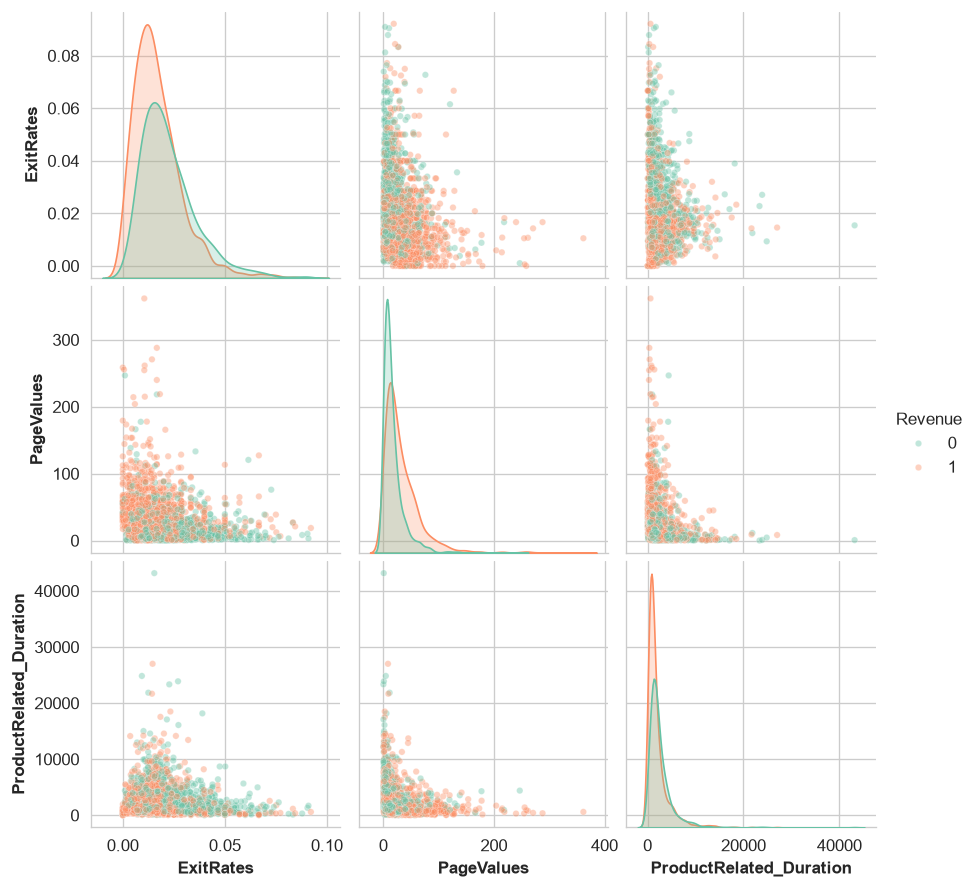

In [680]:
sns.pairplot(df[df['PageValues'] > 0][['ExitRates', 'PageValues', 'ProductRelated_Duration', 'Revenue']],
             hue='Revenue', palette='Set2', plot_kws={'alpha': 0.4, 's': 15})
plt.show()

In [681]:
print(f'После отсечения некоммерческих сайтов доля доходных сессий выросла до {df[df['PageValues'] > 0]['Revenue'].mean()*100:0.2f}%')

После отсечения некоммерческих сайтов доля доходных сессий выросла до 56.15%


Рассмотрим корреляцию признаков:

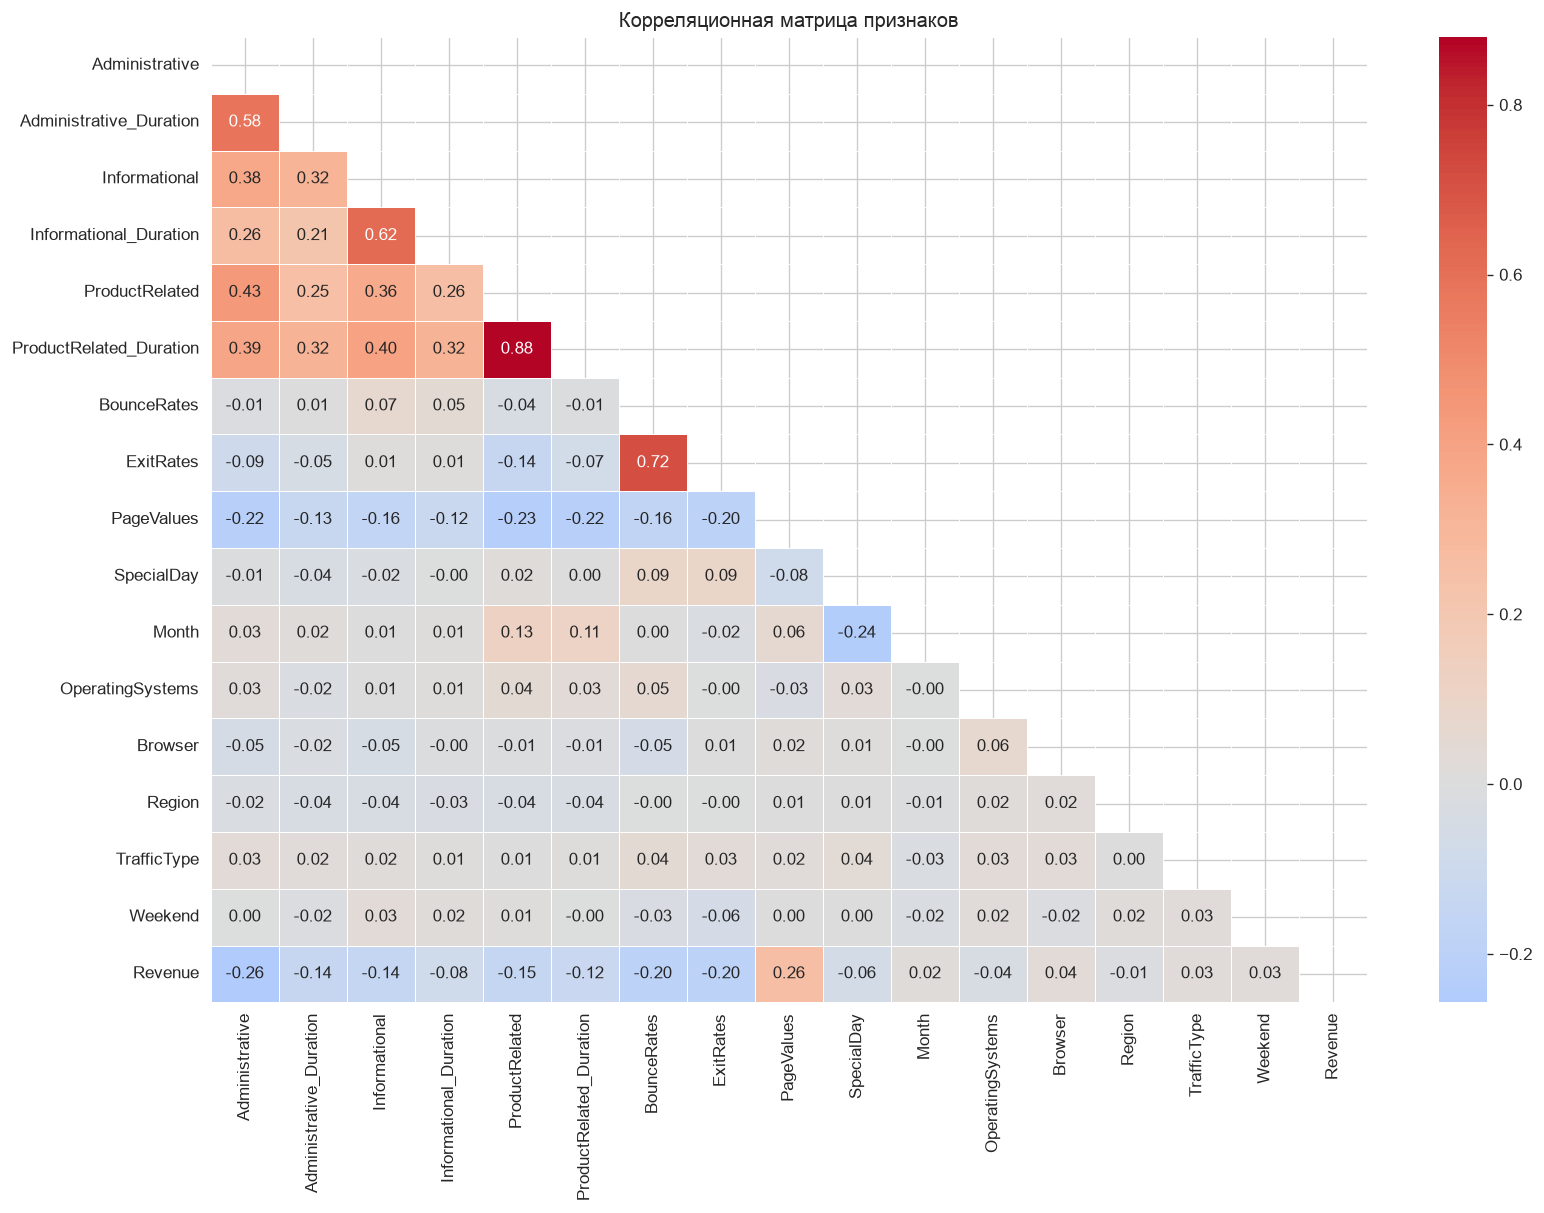

In [682]:
fig = plt.figure(figsize=(14,10))

numeric_columns = df[df['PageValues'] > 0].select_dtypes(include=np.number).columns.tolist()
corr = df[df['PageValues'] > 0][numeric_columns].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0, 
            linewidths=0.5)

plt.tight_layout()
plt.title("Корреляционная матрица признаков");

## 2. Классификация: логистическая регрессия

In [683]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error, f1_score, 
                             accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score, 
                             precision_recall_curve, average_precision_score, log_loss, 
                             ConfusionMatrixDisplay, confusion_matrix)

SEED = 42

In [684]:
key_columns = ['Administrative', 'Informational', 'ProductRelated', 'Administrative_Duration',
               'Informational_Duration', 'ProductRelated_Duration', 'ExitRates', 'PageValues', 
               'VisitorType', 'Month', 'Weekend', 'SpecialDay']

df_filtered = df[df['PageValues'] > 0]

X = df_filtered.drop(columns=['Revenue'])
y = df_filtered['Revenue'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f"Соотношение классов в обучающей выборке: {y_train.mean():0.4f}")
print(f"Соотношение классов в тестовой выборке: {y_test.mean():0.4f}")
print("Т.е. стратификация в обучающей и тестовой выборках сохранилась.")

y_train_logreg = y_train
y_test_logreg = y_test

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Соотношение классов в обучающей выборке: 0.5615
Соотношение классов в тестовой выборке: 0.5617
Т.е. стратификация в обучающей и тестовой выборках сохранилась.


Обучим модель логистической регрессии с L2 регуляризацией (устанавливается по умолчания в `sklearn`) с параметром $\lambda_2 = 1.0$

In [686]:
log_reg_model = LogisticRegression(max_iter=1000, random_state=SEED)

log_reg_model.fit(X_train_sc, y_train)
y_hat = log_reg_model.predict(X_test_sc)
y_score = log_reg_model.predict_proba(X_test_sc)[:, 1]

In [687]:
print('Предсказания логистической регрессии примерно воспроизводят стратификацию в оригинальном датасете: ', y_hat.mean().round(3))

Предсказания логистической регрессии примерно воспроизводят стратификацию в оригинальном датасете:  0.589


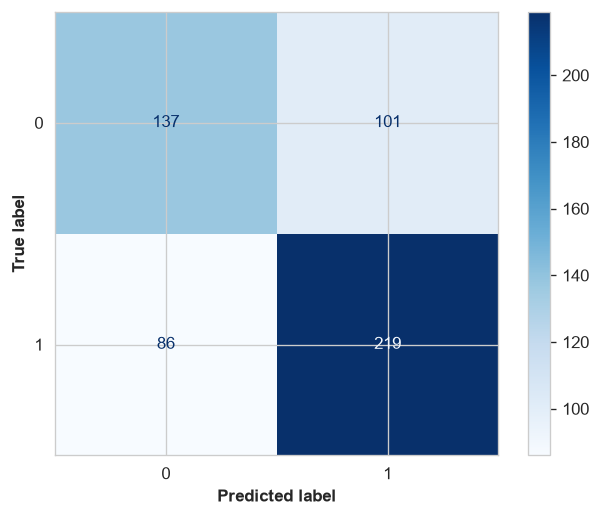

In [688]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, y_hat, ax=ax, cmap='Blues')

In [689]:
pd.DataFrame(
    {'Accuracy': [accuracy_score(y_test, y_hat)],
     'ROC-AUC':   [roc_auc_score(y_test, y_score)],
     'Precision': [precision_score(y_test, y_hat)],
     'Recall':    [recall_score(y_test, y_hat)],
     'F1':        [f1_score(y_test, y_hat)],
     'Log loss':  [log_loss(y_test, y_score)]},
    index=['Ridge LogReg']
)

,Accuracy,ROC-AUC,Precision,Recall,F1,Log loss
Ridge LogReg,0.655617,0.712619,0.684375,0.718033,0.7008,0.610191


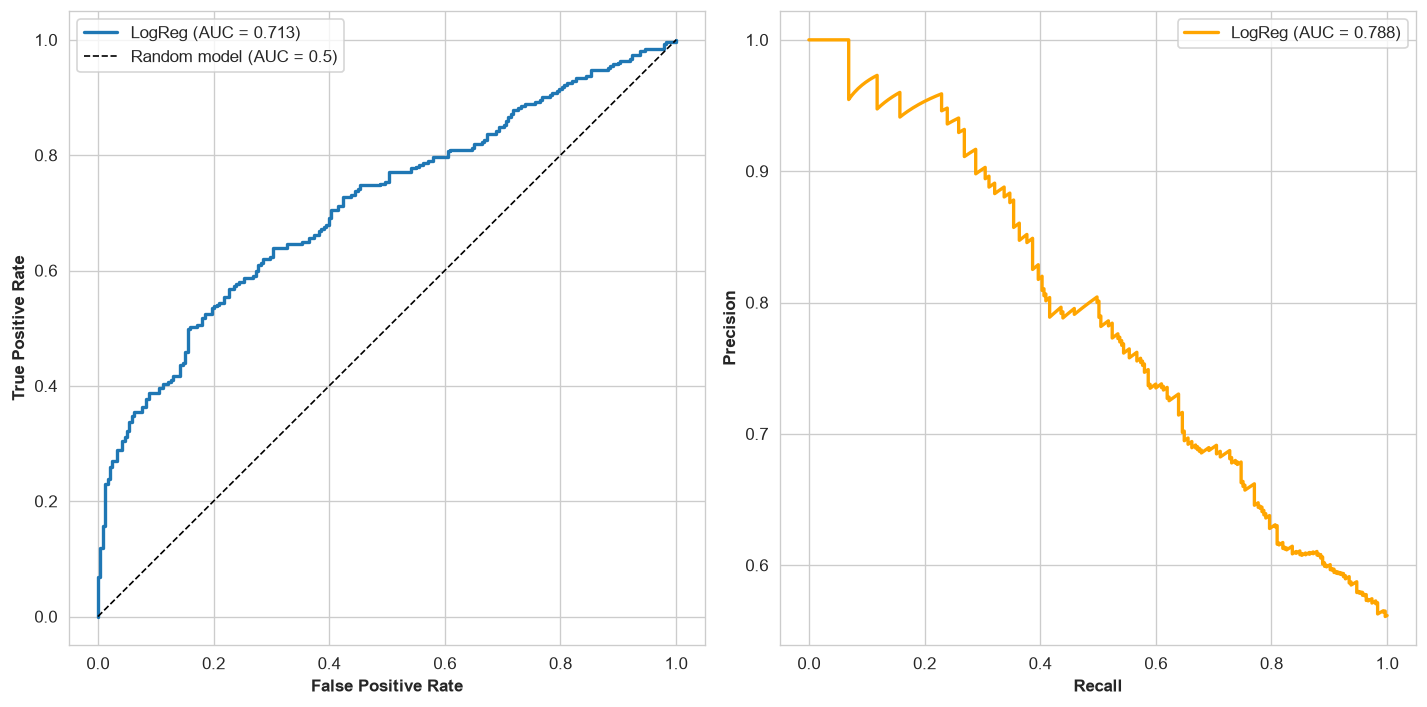

In [690]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

fpr, tpr, _ = roc_curve(y_true=y_test, y_score=y_score)

ax[0].plot(fpr, tpr, linewidth=2, label=f'LogReg (AUC = {roc_auc_score(y_test, y_score):0.3f})')
ax[0].plot([0, 1], [0, 1], linestyle='--', linewidth=1, color='black', label='Random model (AUC = 0.5)')

ax[0].legend()
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].grid(True)

precision, recall, _ = precision_recall_curve(y_test, y_score)
aver_precision = average_precision_score(y_test, y_score)
ax[1].plot(recall, precision, linewidth=2, color='orange', label=f'LogReg (AUC = {aver_precision:0.3f})')

ax[1].set_xlabel("Recall")
ax[1].set_ylabel('Precision')
ax[1].legend()
ax[1].grid(True)

fig.tight_layout()


**Для сравнения:**

- оригинальный датасет без отбора признаков имеет значительный дизбаланс классов 15.5% $\to$ метрики `ROC-AUC` и `Accuracy` не применимы в таком случае. Так, например, аналогичная модель логистической регрессии выдает `ROC-AUC = 0.883` на датасете с дизбалансом, что **некорректо**

- при текущем отборе `PageValues > 0` в датасете наблюдается примерный баланс классов 56.15% $\to$ метрика `ROC-AUC = 0.731`, меньше чем в первом сценарии, **НО(!)** в данном случае метрика `ROC-AUC` адекватно оценивает качество классификации.
 
Рассмотрим способы улучшить модель.

### 2.1 Кросс-валидация и подбор гиперпараметров для логистической регрессии

In [691]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

In [805]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, solver='saga', random_state=SEED))
])

lr_params = {'model__l1_ratio': np.linspace(0., 1., 5),
               'model__C':        np.linspace(0.1, 10, 10)}

lr_search = GridSearchCV(pipeline, lr_params, cv=cv, scoring='average_precision')
lr_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': array([ 0.1, ..., 8.9, 10. ]), 'model__l1_ratio': array([0. , ..., 0.75, 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [806]:
lr_search.best_params_, lr_search.best_score_

({'model__C': np.float64(0.1), 'model__l1_ratio': np.float64(1.0)},
 np.float64(0.7924310014011825))

In [823]:
log_reg_best = LogisticRegression(max_iter=1000,
                                solver='saga', 
                                random_state=SEED, 
                                C=lr_search.best_params_['model__C'],
                                l1_ratio=lr_search.best_params_['model__l1_ratio'])

log_reg_best.fit(X_train_sc, y_train)
y_hat_lr = log_reg_best.predict(X_test_sc)
y_score_lr = log_reg_best.predict_proba(X_test_sc)[:, 1]

y_test_lr = y_test

In [808]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', log_reg_best)
])

cv_score = cross_val_score(pipeline, X_train_sc, y_train, cv=cv, scoring='f1_macro')
cv_score

array([0.66883456, 0.63490078, 0.69046261, 0.61697556, 0.66565589])

In [809]:
pd.DataFrame(
    {'Accuracy':  [accuracy_score(y_test, y_hat_lr)],
     'ROC-AUC':   [roc_auc_score(y_test, y_score_lr)],
     'Precision': [precision_score(y_test, y_hat_lr)],
     'Recall':    [recall_score(y_test, y_hat_lr)],
     'F1':        [f1_score(y_test, y_hat_lr)],
     'PR-AUC':    [average_precision_score(y_test, y_score_lr)],
     'F1 (macro) CV': [f"{cv_score.mean():0.4f} +- {cv_score.std():0.4f}"]},
    index=['LogReg (Lasso)']
)

,Accuracy,ROC-AUC,Precision,Recall,F1,PR-AUC,F1 (macro) CV
LogReg (Lasso),0.664825,0.712798,0.691589,0.727869,0.709265,0.7892,0.6554 +- 0.0261


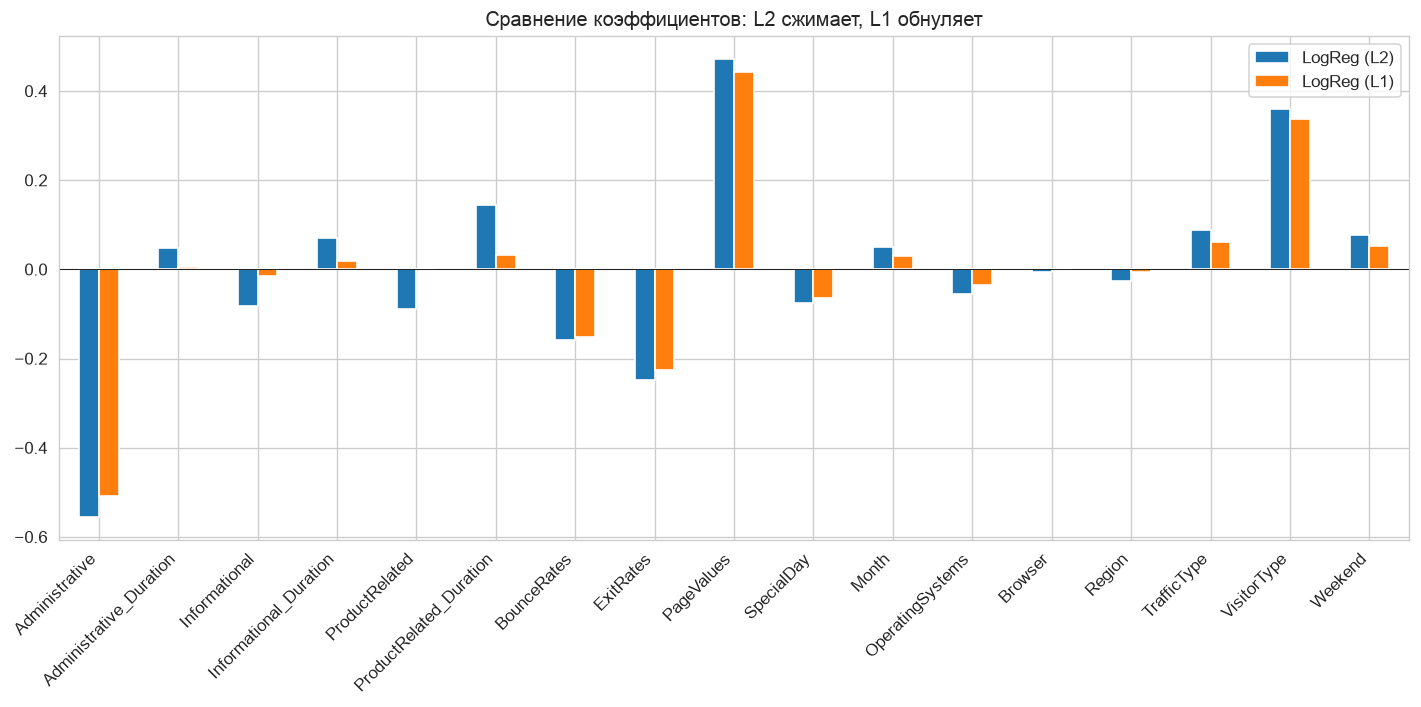

In [697]:
models = {'LogReg (L2)': log_reg_model, 'LogReg (L1)': log_reg_cv}

coefs = pd.DataFrame({
    name: model.coef_[0] for name, model in models.items()
}, index=X.columns)

fig, ax = plt.subplots(figsize=(12, 6))
coefs[['LogReg (L2)', 'LogReg (L1)']].plot.bar(ax=ax)
ax.set_title('Сравнение коэффициентов: L2 сжимает, L1 обнуляет')
ax.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

В целом, модель логистической регрессии справляется с выявлением доходных сессий.

Линейная модель производит разделение объектов двух категорий путем построения разделяющей плоскости в $\mathbb{R}^p$, где $p$ - количество признаков, в то время как точки двух категорий имеют плотное пересекающиеся распределение, что было продемонстрировано в разделе `EDA`.

Например, продублируем распределение точек в плоскости `ExitRate` и `PageValues` вместе с разделяюзей прямой:

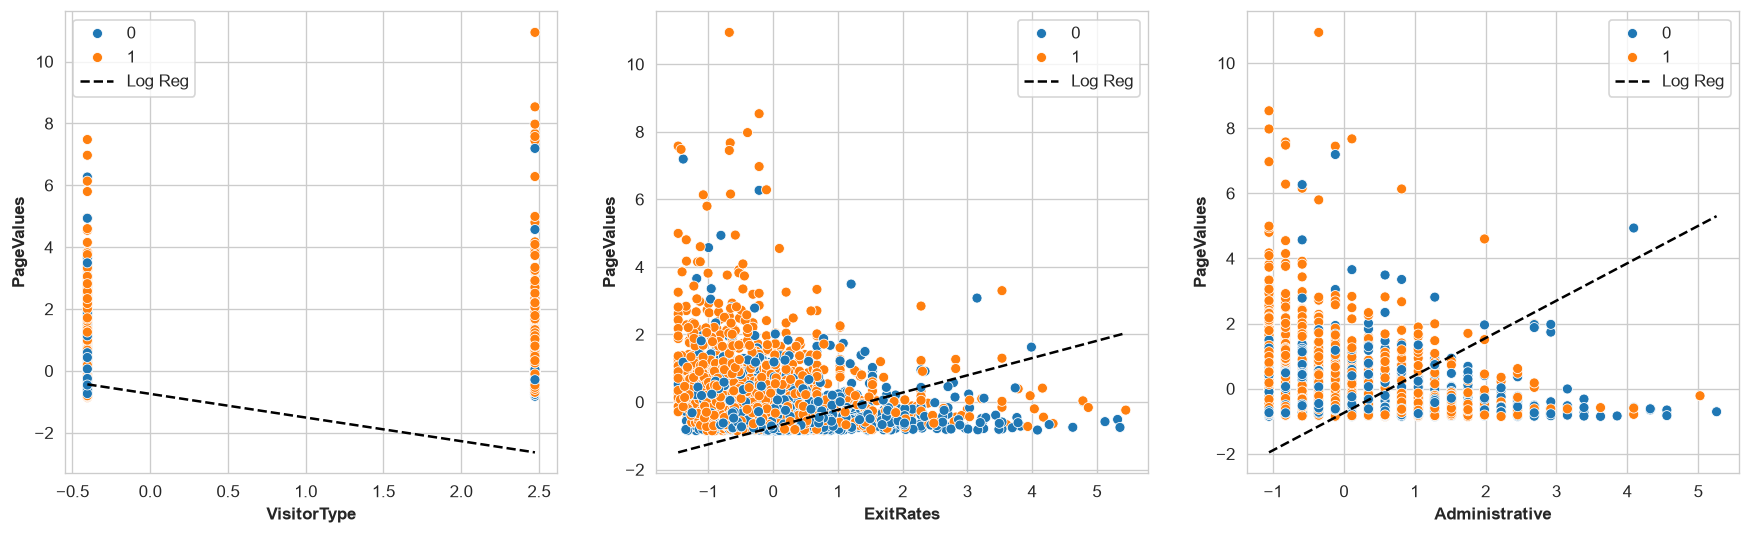

In [698]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

features = ['PageValues', 'VisitorType', 'ExitRates', 'Administrative']
idx = [X.columns.get_loc(feature) for feature in features]
w = [log_reg_cv.coef_[0][i] for i in idx]
b = log_reg_cv.intercept_

X_scaled = scaler.fit_transform(X)

for i in range(len(features)-1):
    w1, w2 = log_reg_cv.coef_[0][idx[i+1]], log_reg_cv.coef_[0][idx[0]]
    x1 = np.linspace(X_scaled[:, idx[i+1]].min(), X_scaled[:, idx[i+1]].max(), 200)
    x2 = -(w1*x1 + b)/w2
    sns.scatterplot(x=X_scaled[:, idx[i+1]], y=X_scaled[:, idx[0]], hue=y, ax=ax[i])
    ax[i].plot(x1, x2, color="black", linestyle='--', label='Log Reg')

    ax[i].legend()
    ax[i].set_xlabel(features[i+1])
    ax[i].set_ylabel(features[0])


Более сложные модели, способные к нелинейному разделению точек в пространстве признаков, в перспективе смогут улавливать кластеризации точек и нелинейные разделяющие поверхности.

Рассмотрим такие модели.

## 3. Классификация: случайный лес

In [699]:
from sklearn.ensemble import RandomForestClassifier

Для случайного дерева будем использовать все признаки и без предварительного отбора `PageValues > 0`, в предположении, что `Random Forset` обнаружит этот отбор:

In [770]:
# [df['PageValues'] > 0]
X_all = df.drop(columns=['Revenue'])
y_all = df['Revenue'].values

rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

rf.fit(X_train, y_train)
y_hat = rf.predict(X_test)
y_score = rf.predict_proba(X_test)[:, 1]

In [701]:
print(y_all.mean())
print(y_hat.mean())

0.1545120457329522
0.11637403021641486


В данном случае метрики `Accuracy` и `ROC-AUC` использовать некорректо из-за дизбаланса классов.

In [702]:
rf_cv_score = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_macro')

pd.DataFrame(
    {'Accuracy':  [accuracy_score(y_test, y_hat)],
     'ROC-AUC':   [roc_auc_score(y_test, y_score)],
     'Precision': [precision_score(y_test, y_hat)],
     'Recall':    [recall_score(y_test, y_hat)],
     'F1':        [f1_score(y_test, y_hat)],
     'F1 (macro)': [f"{rf_cv_score.mean():0.4f} +- {rf_cv_score.std():0.4f}"]},
    index=['RF(200)']
)

,Accuracy,ROC-AUC,Precision,Recall,F1,F1 (macro)
RF(200),0.907309,0.932734,0.764912,0.57672,0.657617,0.7887 +- 0.0139


In [703]:
rf_cv_score = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_macro')
rf_cv_score

array([0.81367931, 0.77908727, 0.7833506 , 0.77456988, 0.79261281])

### Подбор гиперпараметров для модели случайного леса

In [815]:
param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1
)
rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 5, ...], 'max_features': ['auto', 'sqrt', ...], 'n_estimators': [200, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Sup

In [816]:
rf_search.best_params_, rf_search.best_score_.round(4)

({'criterion': 'entropy',
  'max_depth': 8,
  'max_features': 'sqrt',
  'n_estimators': 500},
 np.float64(0.6905))

In [824]:
rf_best = RandomForestClassifier(random_state=SEED, n_jobs=-1, **rf_search.best_params_)

rf_best.fit(X_train, y_train)
y_hat_rf = rf_best.predict(X_test)
y_score_rf = rf_best.predict_proba(X_test)[:, 1]

In [818]:
rf_cv_score = cross_val_score(rf_best, X_train, y_train, cv=cv, scoring='f1_macro')

pd.DataFrame(
    {'Accuracy':  [accuracy_score(y_test, y_hat_rf)],
     'ROC-AUC':   [roc_auc_score(y_test, y_score_rf)],
     'Precision': [precision_score(y_test, y_hat_rf)],
     'Recall':    [recall_score(y_test, y_hat_rf)],
     'F1':        [f1_score(y_test, y_hat_rf)],
     'F1 (macro)': [f"{rf_cv_score.mean():0.4f} +- {rf_cv_score.std():0.4f}"]},
    index=['RF(200)']
)

,Accuracy,ROC-AUC,Precision,Recall,F1,F1 (macro)
RF(200),0.71639,0.78132,0.75945,0.72459,0.741611,0.6905 +- 0.0261


### Отбор признаков

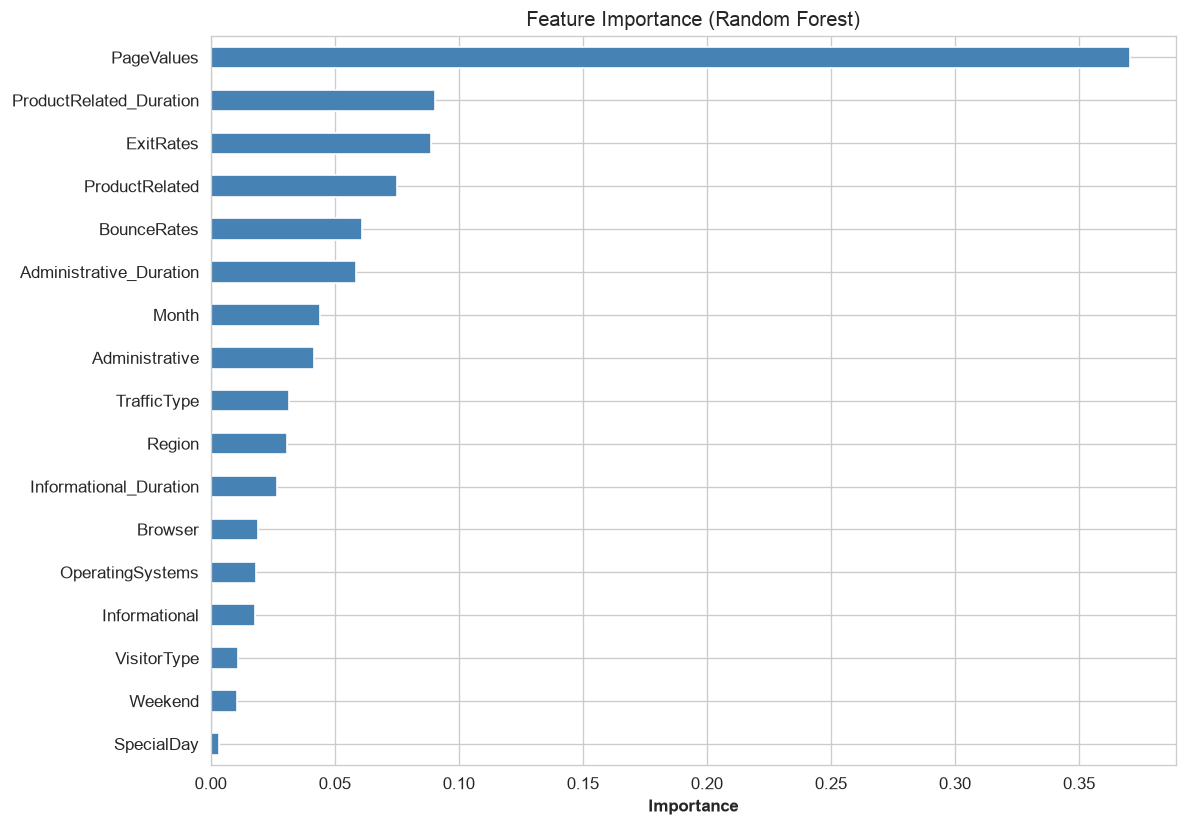

In [709]:
# best_dt = grid_search.best_estimator_

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

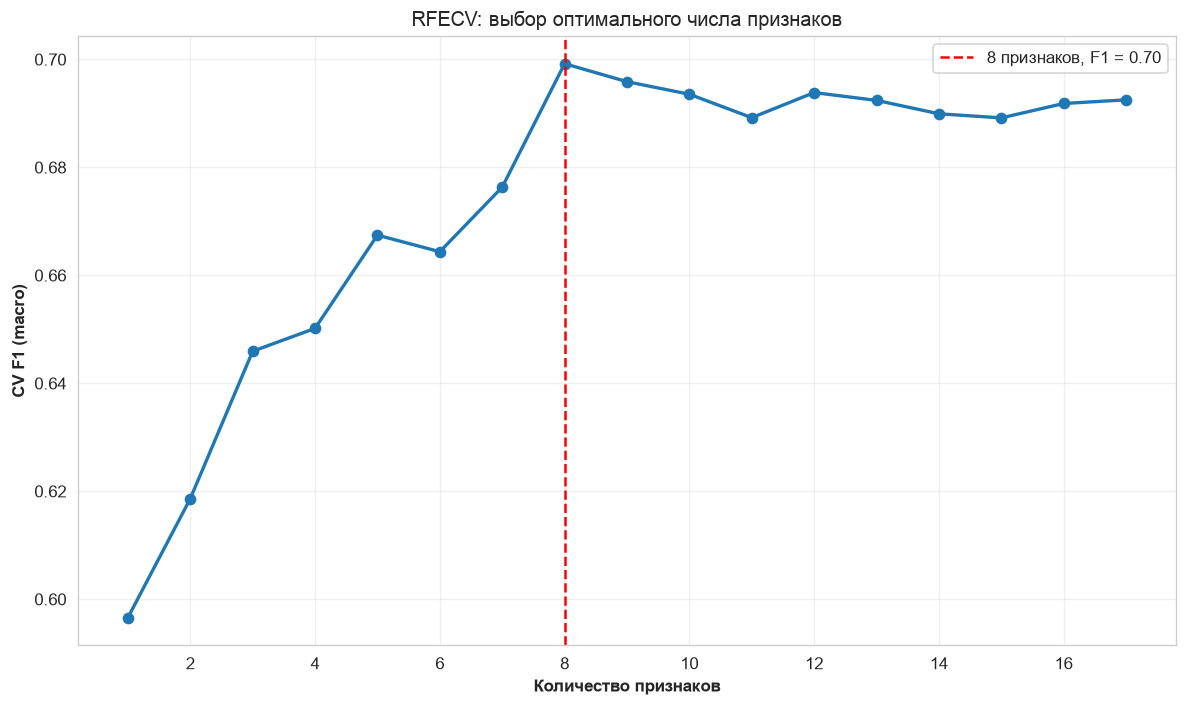

In [819]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(estimator=rf_best,
              step=1, cv=5, scoring='f1_macro', n_jobs=-1)
rfecv.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
        rfecv.cv_results_['mean_test_score'], 'o-', linewidth=2)
ax.axvline(rfecv.n_features_, color='red', linestyle='--', 
           label=f'{rfecv.n_features_} признаков, F1 = {np.max(rfecv.cv_results_['mean_test_score']):0.2f}')
ax.set_xlabel('Количество признаков')
ax.set_ylabel('CV F1 (macro)')
ax.set_title('RFECV: выбор оптимального числа признаков')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [734]:
selected_features_rfecv = X.columns[rfecv.support_].tolist()
selected_features_rfecv

['Administrative_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'Month']

In [828]:
df_tmp = df
# df_tmp = df[df['PageValues'] > 0]

X_sel = df_tmp[selected_features_rfecv]
y_sel = df_tmp['Revenue'].values

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_sel, y_sel, test_size=0.2, random_state=SEED, stratify=y_sel)

rf_best.fit(X_train_sel, y_train_sel)

y_hat_sel = rf_best.predict(X_test_sel)
y_score_sel = rf_best.predict_proba(X_test_sel)[:, 1]

y_hat_rf = y_hat_sel
y_score_rf = y_score_sel
y_test_rf = y_test_sel

In [826]:
rf_best_cv_score = cross_val_score(rf_best, X_train, y_train, cv=cv, scoring='f1_macro')

pd.DataFrame(
    {'Accuracy':  [accuracy_score(y_test_sel, y_hat_sel)],
     'ROC-AUC':   [roc_auc_score(y_test_sel, y_score_sel)],
     'Precision': [precision_score(y_test_sel, y_hat_sel)],
     'Recall':    [recall_score(y_test_sel, y_hat_sel)],
     'F1':        [f1_score(y_test_sel, y_hat_sel)],
     'F1 (macro)': [f"{rf_best_cv_score.mean():0.4f} +- {rf_best_cv_score.std():0.4f}"]},
    index=['RF(200)']
)

,Accuracy,ROC-AUC,Precision,Recall,F1,F1 (macro)
RF(200),0.909351,0.939567,0.784672,0.568783,0.659509,0.6905 +- 0.0261


In [796]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_sel, y_train_sel)

rf_best.fit(X_train_smote, y_train_smote)
y_hat_rf = rf_best.predict(X_test_sel)
y_score_rf = rf_best.predict_proba(X_test_sel)[:, 1]

In [797]:
rf_best_cv_score = cross_val_score(rf_best, X_train_smote, y_train_smote, cv=cv, scoring='f1_macro')

pd.DataFrame(
    {'Accuracy':  [accuracy_score(y_test_sel, y_hat_rf)],
     'ROC-AUC':   [roc_auc_score(y_test_sel, y_score_rf)],
     'Precision': [precision_score(y_test_sel, y_hat_rf)],
     'Recall':    [recall_score(y_test_sel, y_hat_rf)],
     'F1':        [f1_score(y_test_sel, y_hat_rf)],
     'F1 (macro)': [f"{rf_best_cv_score.mean():0.4f} +- {rf_best_cv_score.std():0.4f}"]},
    index=['RF(200)']
)

,Accuracy,ROC-AUC,Precision,Recall,F1,F1 (macro)
RF(200),0.887709,0.932739,0.602386,0.801587,0.687855,0.9059 +- 0.0042


## 4. Модель XGBoost

In [834]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,# Controls how much each tree contributes.
    subsample=0.8, # Means every tree uses only 80% of rows randomly.
    colsample_bytree=0.8,# Controls how many features are used for each tree.
    random_state=42,
    eval_metric='logloss' # Loss function used during training., logloss: Measures prediction error using probabilities.
)

X_train['VisitorType'] = X_train['VisitorType'].astype(np.int64)
X_test['VisitorType'] = X_test['VisitorType'].astype(np.int64)

xgb_model.fit(X_train, y_train)

y_hat_xgb = xgb_model.predict(X_test)
y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_test_xgb = y_test

In [784]:
xgb_cv_score = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='f1_macro')

pd.DataFrame(
    {'Accuracy':  [accuracy_score(y_test, y_hat_xgb)],
     'ROC-AUC':   [roc_auc_score(y_test, y_score_xgb)],
     'Precision': [precision_score(y_test, y_hat_xgb)],
     'Recall':    [recall_score(y_test, y_hat_xgb)],
     'F1':        [f1_score(y_test, y_hat_xgb)],
     'F1 (macro)': [f"{xgb_cv_score.mean():0.4f} +- {xgb_cv_score.std():0.4f}"]},
    index=['XGB']
)

,Accuracy,ROC-AUC,Precision,Recall,F1,F1 (macro)
XGB,0.913026,0.942099,0.772277,0.619048,0.687225,0.7918 +- 0.0129


In [787]:
xgb_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = GridSearchCV(xgb_model, xgb_params, cv=cv, scoring='f1_macro')

xgb_search.fit(X_train, y_train)

y_hat_xgb = xgb_model.predict(X_test)
y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [788]:
xgb_search.best_params_, xgb_search.best_score_

({'colsample_bytree': 1.0,
  'learning_rate': 0.05,
  'max_depth': 3,
  'n_estimators': 150,
  'subsample': 0.8},
 np.float64(0.8014890969036406))

In [791]:
xgb_best = XGBClassifier(**xgb_search.best_params_)

xgb_best.fit(X_train, y_train)

y_hat_xgb = xgb_best.predict(X_test)
y_score_xgb = xgb_best.predict_proba(X_test)[:, 1]

In [792]:
xgb_cv_score = cross_val_score(xgb_best, X_train, y_train, cv=cv, scoring='f1_macro')

pd.DataFrame(
    {'Accuracy':  [accuracy_score(y_test, y_hat_xgb)],
     'ROC-AUC':   [roc_auc_score(y_test, y_score_xgb)],
     'Precision': [precision_score(y_test, y_hat_xgb)],
     'Recall':    [recall_score(y_test, y_hat_xgb)],
     'F1':        [f1_score(y_test, y_hat_xgb)],
     'F1 (macro)': [f"{xgb_cv_score.mean():0.4f} +- {xgb_cv_score.std():0.4f}"]},
    index=['XGB']
)

,Accuracy,ROC-AUC,Precision,Recall,F1,F1 (macro)
XGB,0.911801,0.943912,0.764706,0.619048,0.684211,0.8032 +- 0.0137


## 5. Сравнение моделей

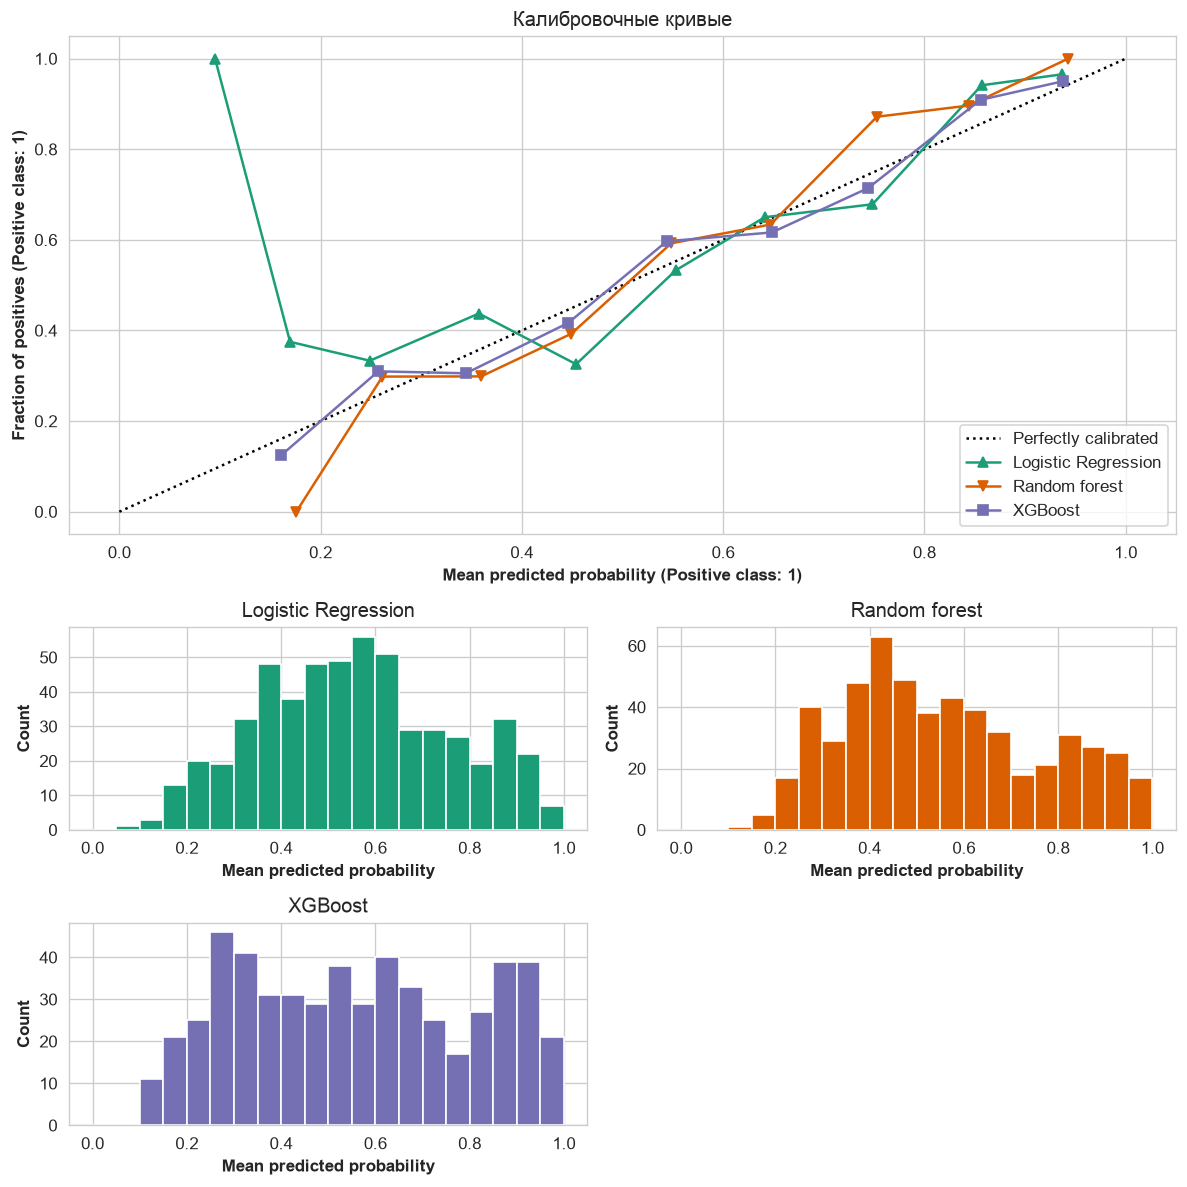

In [837]:
from matplotlib.gridspec import GridSpec
from sklearn.calibration import CalibrationDisplay

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.get_cmap("Dark2")

clf_list = [
    (log_reg_best, "Logistic Regression"),
    (rf_best,      "Random forest"),
    (xgb_best,     "XGBoost")
]

ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}
markers = ["^", "v", "s", "o"]
for i, (clf, name) in enumerate(clf_list):
    X_train_i, X_test_i, y_train_i, y_test_i = X_train, X_test, y_train, y_test
    if (i == 0): # для логрег нужно передать нормированные данные
         X_train_i, X_test_i, y_train_i, y_test_i = X_train_sc, X_test_sc, y_train_logreg, y_test_logreg

    clf.fit(X_train_i, y_train_i)
    display = CalibrationDisplay.from_estimator(
        clf,
        X_test_i,
        y_test_i,
        n_bins=10,
        name=name,
        ax=ax_calibration_curve,
        color=colors(i),
        marker=markers[i],
    )
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Калибровочные кривые")
ax_calibration_curve.grid(True)

# Add histogram
grid_positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])

    ax.hist(
        calibration_displays[name].y_prob,
        range=(0, 1),
        bins=20,
        label=name,
        color=colors(i),
        edgecolor='white'
    )
    ax.set(title=name, xlabel="Mean predicted probability", ylabel="Count")

plt.tight_layout()
plt.show()

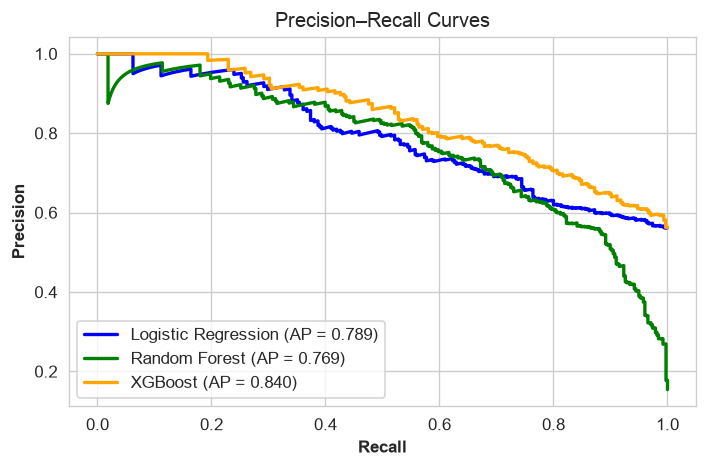

In [835]:

fig, ax = plt.subplots(figsize=(6, 4))

models = [
    ("Logistic Regression", y_test_lr, y_score_lr, "blue"),
    ("Random Forest", y_test_rf, y_score_rf, "green"),
    ("XGBoost", y_test_xgb, y_score_xgb, "orange"),
]

for name, y_test, y_score, color in models:
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)

    ax.plot(
        recall,
        precision,
        linewidth=2,
        color=color,
        label=f"{name} (AP = {ap:.3f})"
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()